In [18]:
import torch
import garmentiq as giq

from garmentiq.classification.model_definition import tinyViT
from garmentiq.segmentation.model_definition.birefnet import BiRefNet, load_birefnet_config
from garmentiq.landmark.detection.model_definition import PoseHighResolutionNet
from garmentiq.garment_classes import garment_classes
from garmentiq.landmark.derivation.derivation_dict import derivation_dict

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE = "test_images/trouser.jpeg"

## Classification

In [19]:
classifier = giq.classification.load_model(
    model_path="models/tiny_vit_inditex_finetuned.pt",
    model_class=tinyViT,
    model_args={"num_classes": 9, "img_size": (120, 184), "patch_size": 6},
    device=DEVICE,
)

label, probabilities = giq.classification.predict(
    model=classifier,
    image_path=IMAGE,
    classes=sorted(garment_classes),
    resize_dim=(120, 184),
    normalize_mean=[0.8047, 0.7808, 0.7769],
    normalize_std=[0.2957, 0.3077, 0.3081],
    device=DEVICE,
)

print(label, probabilities)

trousers [0.00010777074203360826, 0.009896321222186089, 4.73687905468978e-05, 0.009260148741304874, 0.10367942601442337, 8.950736810220405e-05, 0.876125693321228, 0.0005810380098409951, 0.00021275370090734214]


It predicts trousers.
The probabilities match this sorted class order:
- **long sleeve dress**: 0.01%
- **long sleeve top**: 0.99%
- **short sleeve dress**: 0.00%
- **short sleeve top**: 0.93%
- **shorts**: 10.37%
- **skirt**: 0.01%
- **trousers**: 87.61% ← predicted class
- **vest**: 0.06%
- **vest dress**: 0.02%

## Segmentation

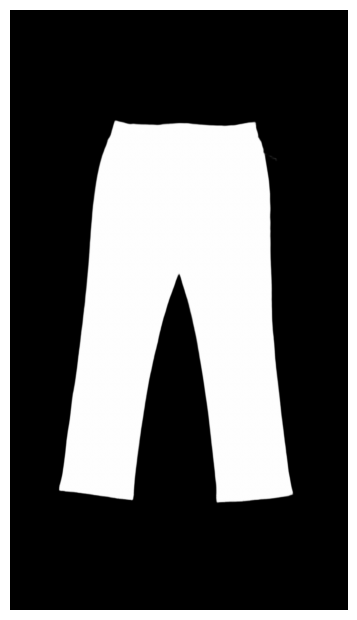

In [20]:
segmenter = giq.segmentation.load_model(
    model_path="models/birefnet/model.safetensors",
    model_class=BiRefNet,
    model_args=load_birefnet_config(),
    device=DEVICE,
)

original, mask = giq.segmentation.extract(
    model=segmenter,
    image_path=IMAGE,
    resize_dim=(1024, 1024),
    normalize_mean=[0.485, 0.456, 0.406],
    normalize_std=[0.229, 0.224, 0.225],
    device=DEVICE,
)

giq.segmentation.plot(mask)

## Landmark detection

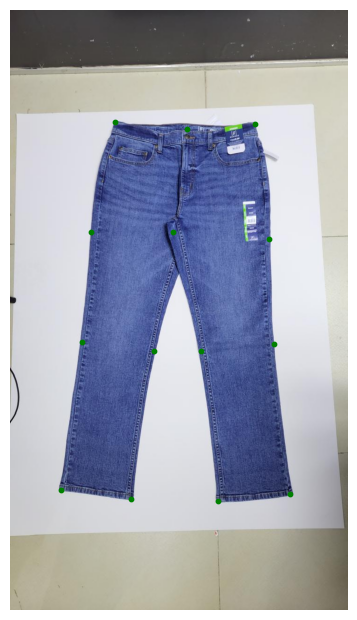

In [21]:
landmark_model = giq.landmark.detection.load_model(
    model_path="models/hrnet.pth",
    model_class=PoseHighResolutionNet(),
    device=DEVICE,
)

coords, confidence, detection = giq.landmark.detect(
    class_name=label,  # or explicitly use "trousers" while testing trousers
    class_dict=garment_classes,
    image_path=IMAGE,
    model=landmark_model,
    scale_std=200.0,
    resize_dim=[288, 384],
    normalize_mean=[0.485, 0.456, 0.406],
    normalize_std=[0.229, 0.224, 0.225],
    device=DEVICE,
)

giq.landmark.plot(IMAGE, coordinate=coords, color="green")

## Refine landmarks using the mask

movement per point (dx, dy):
[[[ 4.5  4.5]
  [-5.5 -5.5]
  [-5.5  3.5]
  [ 4.5 -1.5]
  [ 3.5 -5.5]
  [ 3.5 -5.5]
  [-5.5 -5.5]
  [-5.5 -5.5]
  [-5.5 -5.5]
  [-0.5 -5.5]
  [ 3.5 -5.5]
  [-5.5 -5.5]
  [-5.5 -5.5]
  [-5.5 -5.5]]]


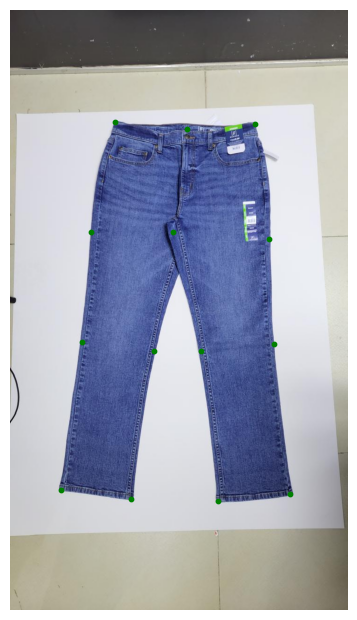

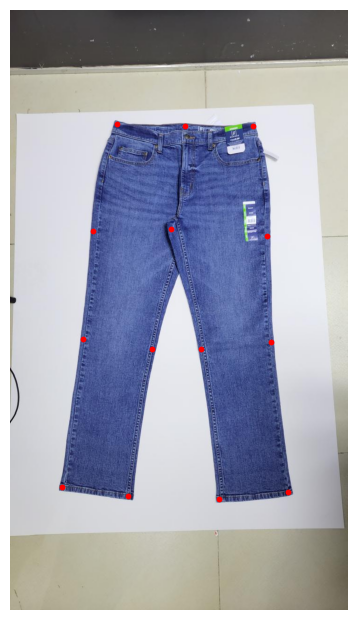

In [23]:
refined_coords, refined_detection = giq.landmark.refine(
    class_name=label,
    detection_np=coords,
    detection_conf=confidence,
    detection_dict=detection,
    mask=mask,
)

print("movement per point (dx, dy):")
print(refined_coords - coords)

giq.landmark.plot(IMAGE, coordinate=coords, color="green")         # before
giq.landmark.plot(IMAGE, coordinate=refined_coords, color="red")   # after


## Derive missing landmarks, then calculate measurements

In [24]:
derived, final_detection = giq.landmark.derive(
    class_name=label,
    detection_dict=refined_detection,
    derivation_dict=derivation_dict,
    landmark_coords=refined_coords,
    np_mask=mask,
)

pixel_measurements, final_detection = giq.utils.compute_measurement_distances(
    final_detection
)

print(pixel_measurements)

{'waist': 290.02758489495443, 'full length': 783.6332050136722, 'front rise': 222.03603311174518, 'hips': 370.1634773988379}


In [25]:
do_refine=True
do_derive=True

In [26]:
metadata, outputs = tailor_biref.measure(
    save_segmentation_image=True,
    save_measurement_image=True,
)

NameError: name 'tailor_biref' is not defined